In [63]:
# Imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [64]:
baseline_df = pd.read_csv(filepath_or_buffer="../timestamp_results/baseline-completed-orders-10000-#1.csv", header=0, sep=',', dtype=np.longlong)
baseline_df
reconfigure_df = pd.read_csv(filepath_or_buffer="../timestamp_results/reconfigure-completed-orders-10011-11-dropped.csv", header=0, sep=',', dtype=np.longlong)
reconfigure_df
rearrange_df = pd.read_csv(filepath_or_buffer="../timestamp_results/rearrange-completed-orders-10014-14-dropped.csv", header=0, sep=',', dtype=np.longlong)
rearrange_df

,COMPLETED_ORDER_COUNT,TIMESTAMP
0,0,1764106745648670100
1,1,1764106746202133938
2,2,1764106746347797430
3,3,1764106746876394695
4,4,1764106747284604378
...,...,...
9996,9996,1764108488286836568
9997,9997,1764108488410155203
9998,9998,1764108488608513084
9999,9999,1764108488901845095


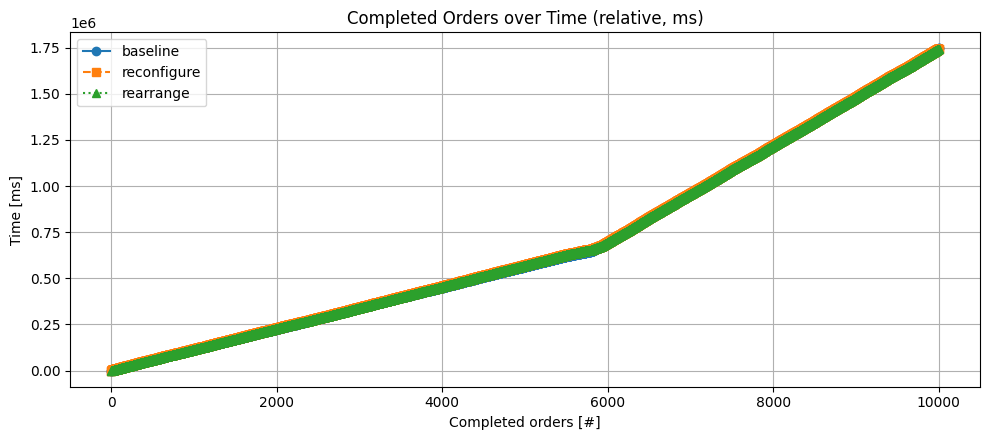

In [65]:
# ensure rel_ms exists for reconfigure and rearrange (baseline already has it)
baseline_start_ts = baseline_df['TIMESTAMP'].iloc[0]
baseline_df['rel_ms'] = (baseline_df['TIMESTAMP'] - baseline_start_ts) / 1e6
reconfigure_start_ts = reconfigure_df['TIMESTAMP'].iloc[0]
reconfigure_df['rel_ms'] = (reconfigure_df['TIMESTAMP'] - reconfigure_start_ts) / 1e6
rearrange_start_ts = rearrange_df['TIMESTAMP'].iloc[0]
rearrange_df['rel_ms'] = (rearrange_df['TIMESTAMP'] - rearrange_start_ts) / 1e6

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
plt.plot(baseline_df['COMPLETED_ORDER_COUNT'], baseline_df['rel_ms'],
         marker='o', linestyle='-', label='baseline')
plt.plot(reconfigure_df['COMPLETED_ORDER_COUNT'], reconfigure_df['rel_ms'],
         marker='s', linestyle='--', label='reconfigure')
plt.plot(rearrange_df['COMPLETED_ORDER_COUNT'], rearrange_df['rel_ms'],
         marker='^', linestyle=':', label='rearrange')

plt.xlabel('Completed orders [#]')
plt.ylabel('Time [ms]')
plt.title('Completed Orders over Time (relative, ms)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
print("baseline makespan: {0} ms".format(baseline_df['rel_ms'].iloc[-1]))
print("reconfigure makespan: {0} ms, {1}% faster".format(reconfigure_df['rel_ms'].iloc[-1], (1-reconfigure_df['rel_ms'].iloc[-1]/baseline_df['rel_ms'].iloc[-1])*1e2))
print("rearrange makespan: {0} ms, {1}% faster".format(rearrange_df['rel_ms'].iloc[-1], (1-rearrange_df['rel_ms'].iloc[-1]/baseline_df['rel_ms'].iloc[-1])*1e2))

baseline makespan: 1745504.480301 ms
reconfigure makespan: 1743176.986137 ms, 0.13334220509125805% faster
rearrange makespan: 1743595.614404 ms, 0.10935898008527234% faster
